# Notebook 03 — Visualizations
## China National Sword: The Export Collapse in Charts

**Charts:**
1. China export volume over time
2. China share of World exports
3. Pre vs Post bar chart
4. Hero chart: waste paper cliff

**Input:** `data/processed/comtrade_clean.csv`
**Output:** `outputs/figures/`

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

df = pd.read_csv('../data/processed/comtrade_clean.csv')
df['cmd_code'] = df['cmd_code'].astype(str)
FIG_DIR = Path('../outputs/figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)

COLORS = {'4707':'#1f77b4','3915':'#ff7f0e','7204':'#2ca02c','7404':'#d62728','7602':'#9467bd'}
SHORT = {'4707':'Waste Paper','3915':'Plastics','7204':'Ferrous','7404':'Copper','7602':'Aluminium'}

print(f'Loaded {len(df)} rows, years: {sorted(df.year.unique())}')
print(df[['year','cmd_code','cmd_name','china_mt','china_share_pct','period']].head(10))

Matplotlib is building the font cache; this may take a moment.


Loaded 44 rows, years: [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]
   year cmd_code                  cmd_name      china_mt  china_share_pct  \
0  2015     3915     Plastic Waste & Scrap    860.956138            41.91   
1  2017     3915     Plastic Waste & Scrap    558.254655            33.40   
2  2018     3915     Plastic Waste & Scrap     48.017968             4.45   
3  2019     3915     Plastic Waste & Scrap     16.910273              NaN   
4  2020     3915     Plastic Waste & Scrap      9.122740             1.46   
5  2021     3915     Plastic Waste & Scrap      1.713991              NaN   
6  2022     3915     Plastic Waste & Scrap      1.880813              NaN   
7  2023     3915     Plastic Waste & Scrap      1.709131             0.40   
8  2015     4707  Waste Paper / Paperboard  13588.884896            69.38   
9  2016     4707  Waste Paper / Paperboard  13189.751000      

## Chart 1 — China Export Volume Over Time

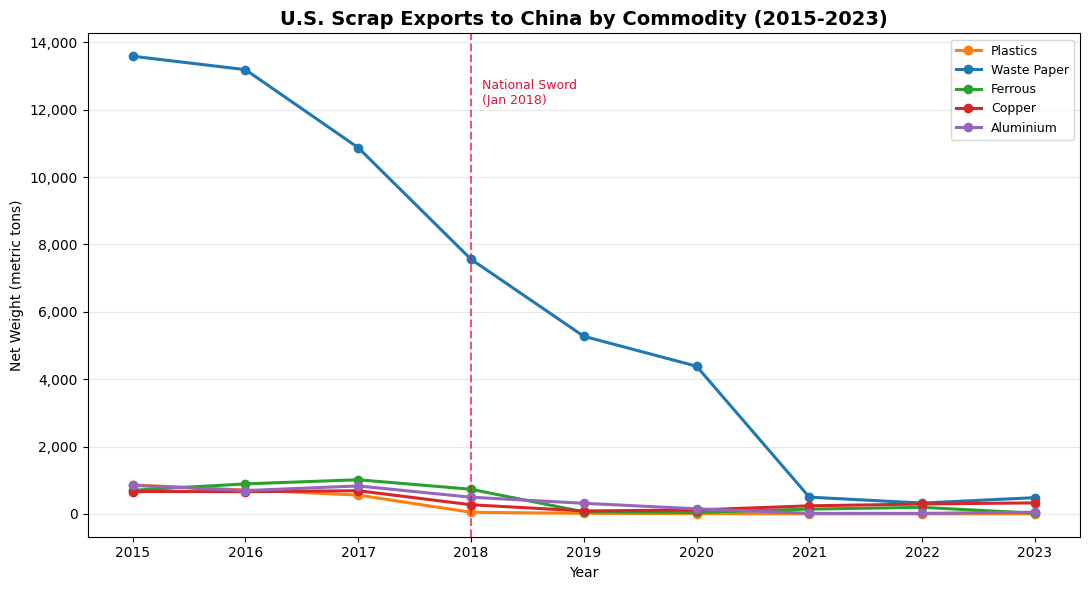

Saved chart 1


In [2]:
fig, ax = plt.subplots(figsize=(11,6))
for cmd, grp in df.groupby('cmd_code'):
    ax.plot(grp['year'], grp['china_mt'], marker='o', linewidth=2.2, color=COLORS[cmd], label=SHORT[cmd])
ax.axvline(2018, color='crimson', linestyle='--', linewidth=1.5, alpha=0.7)
ax.text(2018.1, df['china_mt'].max()*0.95, 'National Sword\n(Jan 2018)', color='crimson', fontsize=9, va='top')
ax.set_title('U.S. Scrap Exports to China by Commodity (2015-2023)', fontsize=14, fontweight='bold')
ax.set_xlabel('Year'); ax.set_ylabel('Net Weight (metric tons)')
ax.legend(loc='upper right', fontsize=9)
ax.set_xticks(range(2015,2024))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{x:,.0f}'))
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR/'china_export_volume.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved chart 1')

## Chart 2 — China Share of World Exports

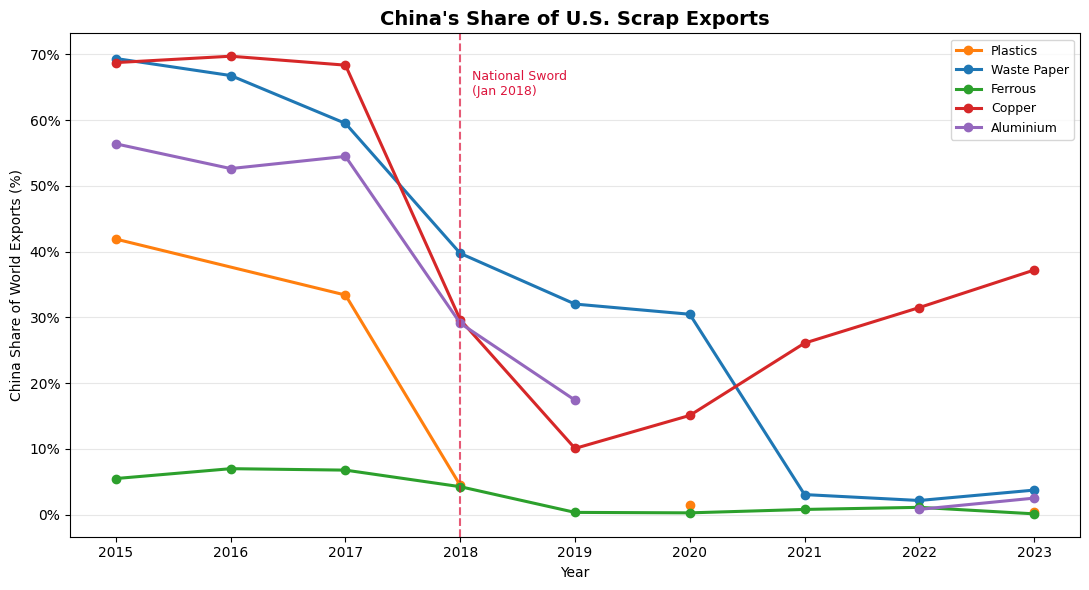

Saved chart 2


In [3]:
fig, ax = plt.subplots(figsize=(11,6))
for cmd, grp in df.groupby('cmd_code'):
    ax.plot(grp['year'], grp['china_share_pct'], marker='o', linewidth=2.2, color=COLORS[cmd], label=SHORT[cmd])
ax.axvline(2018, color='crimson', linestyle='--', linewidth=1.5, alpha=0.7)
ax.text(2018.1, df['china_share_pct'].max()*0.97, 'National Sword\n(Jan 2018)', color='crimson', fontsize=9, va='top')
ax.set_title("China's Share of U.S. Scrap Exports", fontsize=14, fontweight='bold')
ax.set_xlabel('Year'); ax.set_ylabel('China Share of World Exports (%)')
ax.legend(loc='upper right', fontsize=9)
ax.set_xticks(range(2015,2024))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{x:.0f}%'))
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR/'china_share_collapse.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved chart 2')

## Chart 3 — Pre vs Post Bar Chart

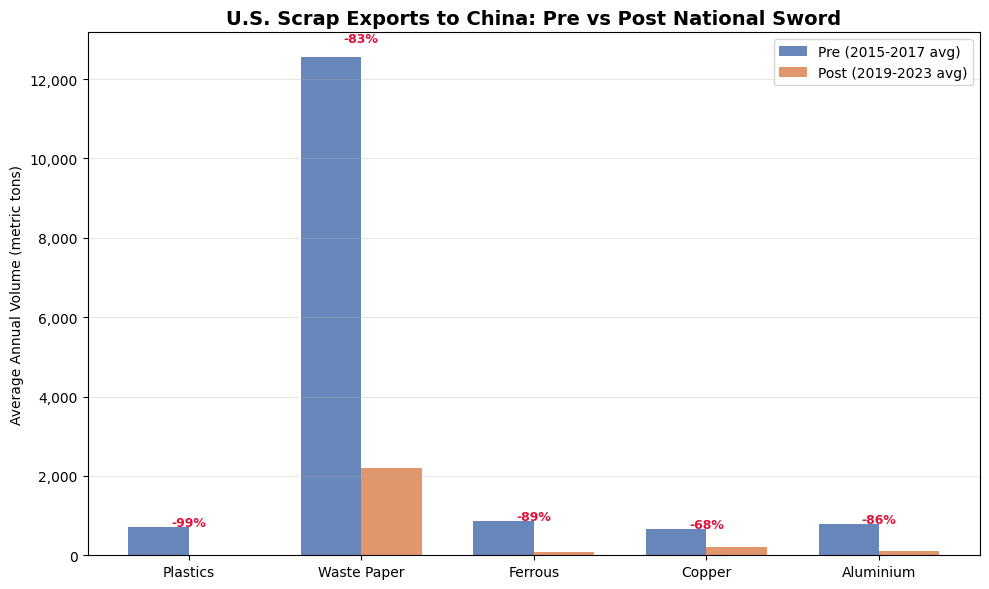

Saved chart 3


In [4]:
pre = df[df['period']=='pre'].groupby('cmd_code')['china_mt'].mean()
post = df[df['period']=='post'].groupby('cmd_code')['china_mt'].mean()
cmds = list(pre.index)
labels = [SHORT[c] for c in cmds]
x = np.arange(len(cmds)); w = 0.35
fig, ax = plt.subplots(figsize=(10,6))
ax.bar(x-w/2, [pre[c] for c in cmds], w, label='Pre (2015-2017 avg)', color='#4C72B0', alpha=0.85)
ax.bar(x+w/2, [post[c] for c in cmds], w, label='Post (2019-2023 avg)', color='#DD8452', alpha=0.85)
for i,c in enumerate(cmds):
    pct = (post[c]-pre[c])/pre[c]*100
    ax.text(i, max(pre[c],post[c])*1.03, f'{pct:.0f}%', ha='center', fontsize=9, color='crimson', fontweight='bold')
ax.set_title('U.S. Scrap Exports to China: Pre vs Post National Sword', fontsize=14, fontweight='bold')
ax.set_ylabel('Average Annual Volume (metric tons)')
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{x:,.0f}'))
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR/'pre_post_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved chart 3')

## Chart 4 — Hero Chart: The Waste Paper Cliff

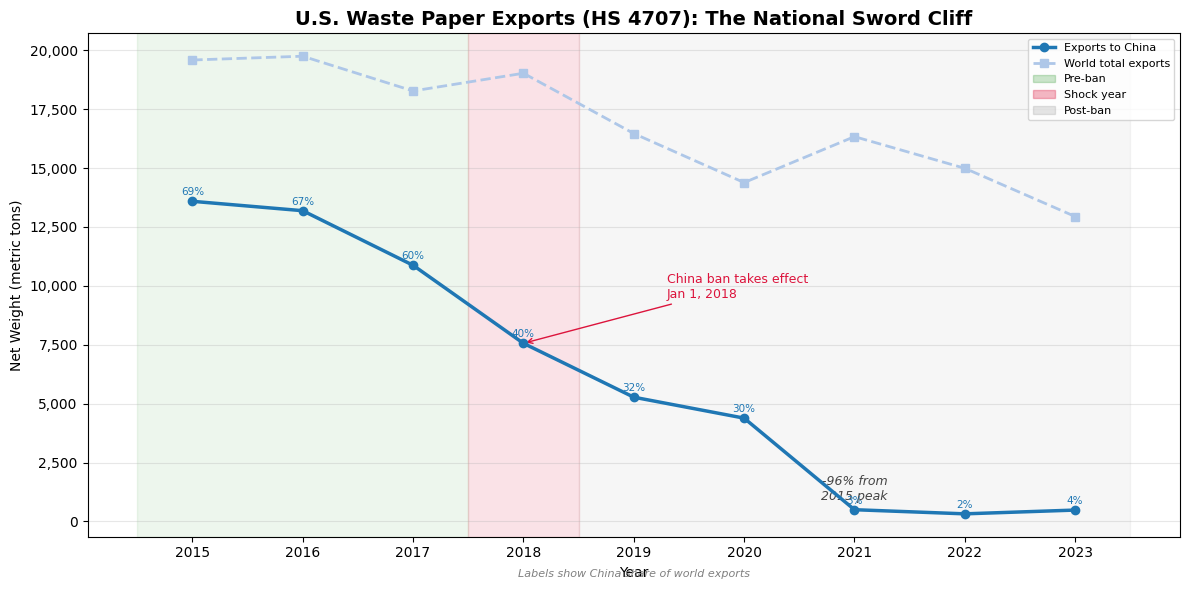

Saved chart 4 — hero chart


In [5]:
from matplotlib.patches import Patch
paper = df[df['cmd_code']=='4707'].sort_values('year')
fig, ax = plt.subplots(figsize=(12,6))
ax.axvspan(2014.5,2017.5,alpha=0.07,color='green')
ax.axvspan(2017.5,2018.5,alpha=0.12,color='crimson')
ax.axvspan(2018.5,2023.5,alpha=0.07,color='gray')
ax.plot(paper['year'],paper['china_mt'],marker='o',linewidth=2.5,color='#1f77b4',zorder=5,label='Exports to China')
ax.plot(paper['year'],paper['world_mt'],marker='s',linewidth=2,color='#aec7e8',linestyle='--',zorder=4,label='World total exports')
china_2018 = paper[paper['year']==2018]['china_mt'].values[0]
ax.annotate('China ban takes effect\nJan 1, 2018',xy=(2018,china_2018),xytext=(2019.3,9500),
    arrowprops=dict(arrowstyle='->',color='crimson'),color='crimson',fontsize=9)
peak = paper[paper['year']==2015]['china_mt'].values[0]
low = paper[paper['year']==2021]['china_mt'].values[0]
pct_drop = (low-peak)/peak*100
ax.text(2021,low+400,f'{pct_drop:.0f}% from\n2015 peak',ha='center',fontsize=9,color='#444',style='italic')
for _,row in paper.iterrows():
    ax.text(row['year'],row['china_mt']+250,f"{row['china_share_pct']:.0f}%",ha='center',fontsize=7.5,color='#1f77b4')
ax.text(0.5,-0.08,'Labels show China share of world exports',transform=ax.transAxes,ha='center',fontsize=8,color='gray',style='italic')
extra = [Patch(color='green',alpha=0.2,label='Pre-ban'),Patch(color='crimson',alpha=0.3,label='Shock year'),Patch(color='gray',alpha=0.2,label='Post-ban')]
handles,lbls = ax.get_legend_handles_labels()
ax.legend(handles=handles+extra,loc='upper right',fontsize=8)
ax.set_title('U.S. Waste Paper Exports (HS 4707): The National Sword Cliff',fontsize=14,fontweight='bold')
ax.set_xlabel('Year'); ax.set_ylabel('Net Weight (metric tons)')
ax.set_xticks(range(2015,2024))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{x:,.0f}'))
ax.grid(axis='y',alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR/'hero_waste_paper_cliff.png',dpi=150,bbox_inches='tight')
plt.show()
print('Saved chart 4 — hero chart')